In [1]:
import gc
gc.collect()

import sys
for path in ['/afs/psi.ch/intranet/SF/Beamdynamics/Harsh/ps_reconstruction/', '/afs/psi.ch/intranet/SF/Beamdynamics/Harsh/']:
    if path not in sys.path:
        sys.path.append(path)

In [2]:
import torch
import h5py
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from ps_reconstruction.core.image_processing import crop_images_to_bright_spot_centers
from ps_reconstruction.core.dataloader import beam_collate_fn, BeamImageDataset, create_beam_dataloader, split_dataset
from ps_reconstruction.utils.visualization import align_images_cross_correlation_cuda, fit_gaussian_to_projection
from ps_reconstruction.core.simulation import ScreenImageGenerator

In [3]:
import h5py

# Load the HDF5 file
# dfile = '/sf/data/measurements/2025/06/30/20250630_193506_EmittanceTool.h5'
dfile = '/sf/data/measurements/2025/05/22/20250522_212838_EmittanceTool.h5'
with h5py.File(dfile, 'r') as f:
    original_r11 = f['/Input/R11'][()]
    original_r12 = f['/Input/R12'][()]
    original_r33 = f['/Input/R33'][()]
    original_r34 = f['/Input/R34'][()]
    x_phase_design = f['/Meta_data/proj_emittance_X/phase_design'][()]
    x_reconstructed = f['/Meta_data/proj_emittance_X/reconstruction'][()]
    x_beamsizes = f['/Meta_data/proj_emittance_X/beamsizes'][()]
    y_phase_design = f['/Meta_data/proj_emittance_Y/phase_design'][()]
    y_reconstructed = f['/Meta_data/proj_emittance_Y/reconstruction'][()]
    y_beamsizes = f['/Meta_data/proj_emittance_Y/beamsizes'][()]
    original_quad_k = f['/Input/QuadK'][()][-1]  # shape: (n_phases,)
    p0c = f['/Input/energy_eV'][()]
    images = f['/Raw_data/image'][()]  # shape: (n_phases, n_images, y, x)
    x_axis = f['/Raw_data/x_axis'][0,0].astype(float)/1e6  # shape: (x,)
    y_axis = f['/Raw_data/y_axis'][0,0].astype(float)/1e6  # shape: (y,)
    screen_res = f['/Input/screen_resolution'][()]  # e.g., (100, 100)

In [8]:
# Apply background subtraction
proc_images = np.array(images, dtype=np.float64) - 1000
proc_images[proc_images < 0 ] = 0

# Select specific indices to use
# This selects the images and corresponding R-matrix values.
# Ensure 'to_use_indices' aligns with the dimensions of original_rXX and proc_images
to_use_indices = [3,4,5,6,7,9,13,14,15,16]
to_use_indices.extend(list(int(i) for i in np.arange(20,30,1)))
# to_use_indices = np.arange(0,31,1)

# Crop images to bright spot centers (apply to the first image of each phase for now)
processed_images_array, processed_x_axis, processed_y_axis = crop_images_to_bright_spot_centers(
    proc_images[:, 0], # Assuming you always use the first image from n_images dimension
    target_x=120, 
    target_y=120, 
    x_axis=x_axis, 
    y_axis=y_axis
)

# Filter all data by to_use_indices
filtered_r11 = original_r11[to_use_indices]
filtered_r12 = original_r12[to_use_indices]
filtered_r33 = original_r33[to_use_indices]
filtered_r34 = original_r34[to_use_indices]
filtered_quad_k = original_quad_k[to_use_indices]

filtered_x_phase_design = x_phase_design[to_use_indices]
filtered_x_reconstructed = x_reconstructed[to_use_indices]
filtered_x_beamsizes = x_beamsizes[to_use_indices]

filtered_y_phase_design = y_phase_design[::-1][to_use_indices]
filtered_y_reconstructed = y_reconstructed[to_use_indices]
filtered_y_beamsizes = y_beamsizes[to_use_indices]

processed_tensors = torch.tensor(processed_images_array[to_use_indices], dtype=torch.float32)

# Ensure R-matrix and quad_k are 1D arrays of values for direct mapping to each sample
# (The DataLoader will stack them later)
quad_torch_k_for_dataset = torch.tensor(filtered_quad_k, dtype=torch.float32).flatten() # Ensure 1D

# Calculate pixel sizes for the cropped images
x_pixel_size = abs(processed_x_axis[0][1] - processed_x_axis[0][0])
y_pixel_size = abs(processed_y_axis[0][1] - processed_y_axis[0][0])
x_pixel_size_tensor = torch.tensor(x_pixel_size, dtype=torch.float32)
y_pixel_size_tensor = torch.tensor(y_pixel_size, dtype=torch.float32)

In [9]:
# Prepare data list for BeamImageDataset
# Each item in `data_list_for_dataset` represents ONE sample with its image and R-matrix parameters.
data_list_for_dataset = []
for i in range(len(to_use_indices)): # Iterate through the already-filtered data
    data_list_for_dataset.append({
        'image': processed_tensors[i], # This is a single 2D image tensor for this sample
        'r11': [filtered_r11[i]],       # A single r11 value for this sample
        'r12': [filtered_r12[i]],
        'r33': [filtered_r33[i]],
        'r34': [filtered_r34[i]],
        'quad_k': quad_torch_k_for_dataset[i] # A single quad_k value for this sample
    })

# Create the full dataset from the prepared list
full_filtered_dataset = BeamImageDataset(data_list_for_dataset)
print(f"Total samples in filtered dataset: {len(full_filtered_dataset)}")

all_filtered_indices = list(range(len(full_filtered_dataset)))
train_indices = [i for i in all_filtered_indices if i % 2 == 0]
test_indices = [i for i in all_filtered_indices if i % 2 != 0]
# train_indices = [0,1,2,3,4,6,8,10,12,14,16,17,18,19]
# test_indices = [5,7,9,11,13,15]

print(f"Train indices: {train_indices}")
print(f"Test indices: {test_indices}")

# Split the dataset
train_ds, test_ds = split_dataset(full_filtered_dataset, train_indices)

print(f"Train dataset size: {len(train_ds)}")
print(f"Test dataset size: {len(test_ds)}")

Total samples in filtered dataset: 20
Train indices: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Test indices: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
Train dataset size: 10
Test dataset size: 10


In [6]:
gt_beam = torch.load(
    "./logs/beam_training/version_40/final_results/reconstructed_beam.pt", weights_only=False
)

In [7]:
gt_beam2 = torch.load(
    "./logs/beam_training/version_63/final_results/reconstructed_beam.pt", weights_only=False
)

In [10]:
lattice = ScreenImageGenerator(filtered_r11, filtered_r12, filtered_r33, filtered_r34, filtered_quad_k, 120, 120, 7.7e-6, 7.8e-6, device= 'cuda')
generated_images = lattice.generate_screen_image(gt_beam, gaussian_blur_sigma=3)
generated_images2 = lattice.generate_screen_image(gt_beam2, gaussian_blur_sigma=3)

Using device: cuda


In [11]:
from ps_reconstruction.core.losses import normalize_images
from ps_reconstruction.utils.visualization import fit_gaussian_to_projection, calculate_rms_projection

normalized_generated_images = normalize_images(generated_images).cpu().numpy()
normalized_orig_images = normalize_images(processed_tensors).cpu().numpy()

orig_sigmas_x, orig_sigmas_y = [], []
pred_sigmas_x, pred_sigmas_y = [], []

orig_rms_x, orig_rms_y = [], []
pred_rms_x, pred_rms_y = [], []

for i in range(20):
    generated_img = normalized_generated_images[i]
    orig_img = normalized_orig_images[i]
    aligned_orig_img = orig_img

    # aligned_orig_img, _ = align_images_cross_correlation_cuda(generated_img, orig_img)

    orig_sigmas_x.append(fit_gaussian_to_projection(aligned_orig_img, axis=0) * x_pixel_size * 1e6)
    orig_sigmas_y.append(fit_gaussian_to_projection(aligned_orig_img, axis=1) * y_pixel_size * 1e6)
    pred_sigmas_x.append(fit_gaussian_to_projection(generated_img, axis=0) * x_pixel_size * 1e6)
    pred_sigmas_y.append(fit_gaussian_to_projection(generated_img, axis=1) * y_pixel_size * 1e6)

    orig_rms_x.append(calculate_rms_projection(aligned_orig_img, axis=0) * x_pixel_size* 1e6)
    orig_rms_y.append(calculate_rms_projection(aligned_orig_img, axis=1) * y_pixel_size* 1e6)
    pred_rms_x.append(calculate_rms_projection(generated_img, axis=0) * x_pixel_size* 1e6)
    pred_rms_y.append(calculate_rms_projection(generated_img, axis=1) * y_pixel_size* 1e6)

In [37]:
from ps_reconstruction.core.losses import normalize_images
from ps_reconstruction.utils.visualization import fit_gaussian_to_projection, calculate_rms_projection

normalized_generated_images2 = normalize_images(generated_images2).cpu().numpy()
normalized_orig_images = normalize_images(processed_tensors).cpu().numpy()

orig_sigmas_x2, orig_sigmas_y2 = [], []
pred_sigmas_x2, pred_sigmas_y2 = [], []

orig_rms_x2, orig_rms_y2 = [], []
pred_rms_x2, pred_rms_y2 = [], []

for i in range(31):
    generated_img = normalized_generated_images2[i]
    orig_img = normalized_orig_images[i]
    aligned_orig_img = orig_img

    # aligned_orig_img, _ = align_images_cross_correlation_cuda(generated_img, orig_img)

    orig_sigmas_x2.append(fit_gaussian_to_projection(aligned_orig_img, axis=0) * x_pixel_size * 1e6)
    orig_sigmas_y2.append(fit_gaussian_to_projection(aligned_orig_img, axis=1) * y_pixel_size * 1e6)
    pred_sigmas_x2.append(fit_gaussian_to_projection(generated_img, axis=0) * x_pixel_size * 1e6)
    pred_sigmas_y2.append(fit_gaussian_to_projection(generated_img, axis=1) * y_pixel_size * 1e6)

    orig_rms_x2.append(calculate_rms_projection(aligned_orig_img, axis=0) * x_pixel_size* 1e6)
    orig_rms_y2.append(calculate_rms_projection(aligned_orig_img, axis=1) * y_pixel_size* 1e6)
    pred_rms_x2.append(calculate_rms_projection(generated_img, axis=0) * x_pixel_size* 1e6)
    pred_rms_y2.append(calculate_rms_projection(generated_img, axis=1) * y_pixel_size* 1e6)

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import os

def create_sigma_comparison(quad_k_np, orig_sigmas_x, orig_sigmas_y, pred_sigmas_x, pred_sigmas_y, 
                           reconstructed_values, measurements, label='Sigma', x_label = 'Quad K'):
    """
    Create sigma comparison plot and CSV with additional data series
    
    Parameters:
    -----------
    quad_k_np : array
        Quadrupole K values
    orig_sigmas_x, orig_sigmas_y : arrays
        Original sigma values for X and Y
    pred_sigmas_x, pred_sigmas_y : arrays  
        Predicted sigma values for X and Y
    reconstructed_values : array
        Additional reconstructed values to plot
    measurements : array
        Additional measurement values to plot
    """
    
    # Create sigma comparison plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Left subplot: Sigma X and additional data
    axes[0].plot(quad_k_np, orig_sigmas_x, c='green', label='Reference Sigma X', marker='o')
    axes[0].plot(quad_k_np, pred_sigmas_x, c='blue', label='Predicted Sigma X', marker='o')
    # axes[0].plot(quad_k_np, reconstructed_values[0], c='green', label='Reconstructed Values', marker='o')
    # axes[0].plot(quad_k_np, measurements[0], c='green', linestyle='--', label='Measurements', marker='d')
    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel(f'{label} X (µm)')
    axes[0].set_title(f'{label} X Values vs {x_label}')
    axes[0].legend()
    axes[0].grid(True)
    
    # Right subplot: Sigma Y and additional data
    axes[1].plot(quad_k_np, orig_sigmas_y, c='green', label='Reference Sigma Y', marker='o')
    axes[1].plot(quad_k_np, pred_sigmas_y, c='blue', label='Predicted Sigma Y', marker='o')
    # axes[1].plot(quad_k_np, reconstructed_values[1], c='green', label='Reconstructed Values', marker='o')
    # axes[1].plot(quad_k_np, measurements[1], c='green', linestyle='--', label='Measurements', marker='d')
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(f'{label} Y (µm)')
    axes[1].set_title(f'{label} Y Values vs {x_label}')
    axes[1].legend()
    axes[1].grid(True)
    
    fig.suptitle('Beam size Comparison')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def create_sigma_comparison_with_phase(filtered_phase_design, orig_sigmas_x, orig_sigmas_y, pred_sigmas_x, pred_sigmas_y, 
                           reconstructed_values, measurements, label='Sigma', x_label = 'Phase Advance'):
    """
    Create sigma comparison plot and CSV with additional data series
    
    Parameters:
    -----------
    quad_k_np : array
        Quadrupole K values
    orig_sigmas_x, orig_sigmas_y : arrays
        Original sigma values for X and Y
    pred_sigmas_x, pred_sigmas_y : arrays  
        Predicted sigma values for X and Y
    reconstructed_values : array
        Additional reconstructed values to plot
    measurements : array
        Additional measurement values to plot
    """
    
    # Create sigma comparison plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Left subplot: Sigma X and additional data
    axes[0].plot(filtered_phase_design[0], orig_sigmas_x, c='green', label='Reference Sigma X', marker='o')
    axes[0].plot(filtered_phase_design[0], pred_sigmas_x, c='blue', label='Predicted Sigma X', marker='o')
    # axes[0].plot(filtered_phase_design[0], reconstructed_values[0], c='green', label='Reconstructed Values', marker='o')
    # axes[0].plot(filtered_phase_design[0], measurements[0], c='green', label='Measurements', marker='d')
    axes[0].set_xlabel('Phase')
    axes[0].set_ylabel(f'{label} X (µm)')
    axes[0].set_title(f'{label} X Values vs Phase advance')
    axes[0].legend()
    axes[0].grid(True)
    
    # Right subplot: Sigma Y and additional data
    axes[1].plot(filtered_phase_design[1], orig_sigmas_y, c='green', label='Reference Sigma Y', marker='o')
    axes[1].plot(filtered_phase_design[1], pred_sigmas_y, c='blue', label='Predicted Sigma Y', marker='o')
    # axes[1].plot(filtered_phase_design[1], reconstructed_values[1], c='green', label='Reconstructed Values', marker='o')
    # axes[1].plot(filtered_phase_design[1], measurements[1], c='green', label='Measurements', marker='d')
    axes[1].set_xlabel('Phase')
    axes[1].set_ylabel(f'{label} Y (µm)')
    axes[1].set_title(f'{label} Y Values vs Phase advance')
    axes[1].legend()
    axes[1].grid(True)
    
    fig.suptitle('Beam size Comparison')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

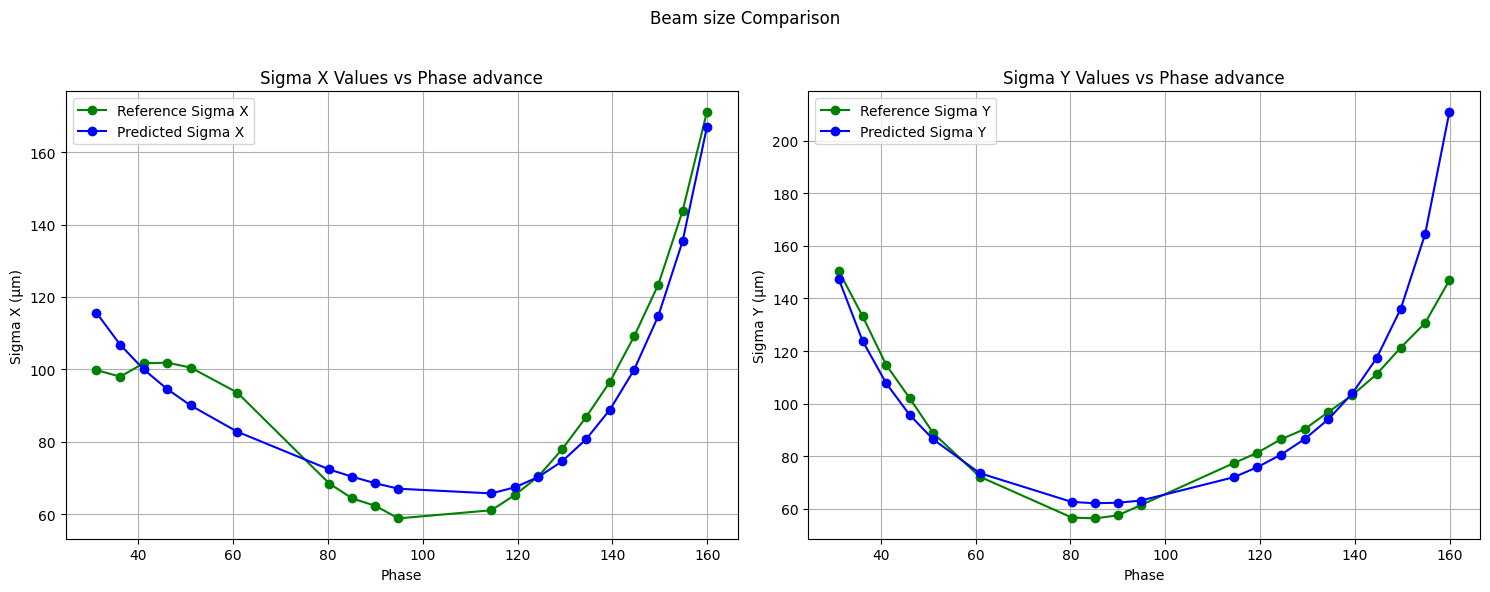

In [14]:
create_sigma_comparison_with_phase(filtered_phase_design=[filtered_x_phase_design, filtered_y_phase_design], 
# create_sigma_comparison(quad_k_np=filtered_quad_k, 
                        orig_sigmas_x=orig_sigmas_x,
                        orig_sigmas_y=orig_sigmas_y,
                        pred_sigmas_x=pred_sigmas_x,
                        pred_sigmas_y=pred_sigmas_y,
                        reconstructed_values=[[k*1e6 for k in filtered_x_reconstructed], [k*1e6 for k in filtered_y_reconstructed]],
                        measurements= [[k*1e6 for k in filtered_x_beamsizes], [k*1e6 for k in filtered_y_beamsizes]]
                        )

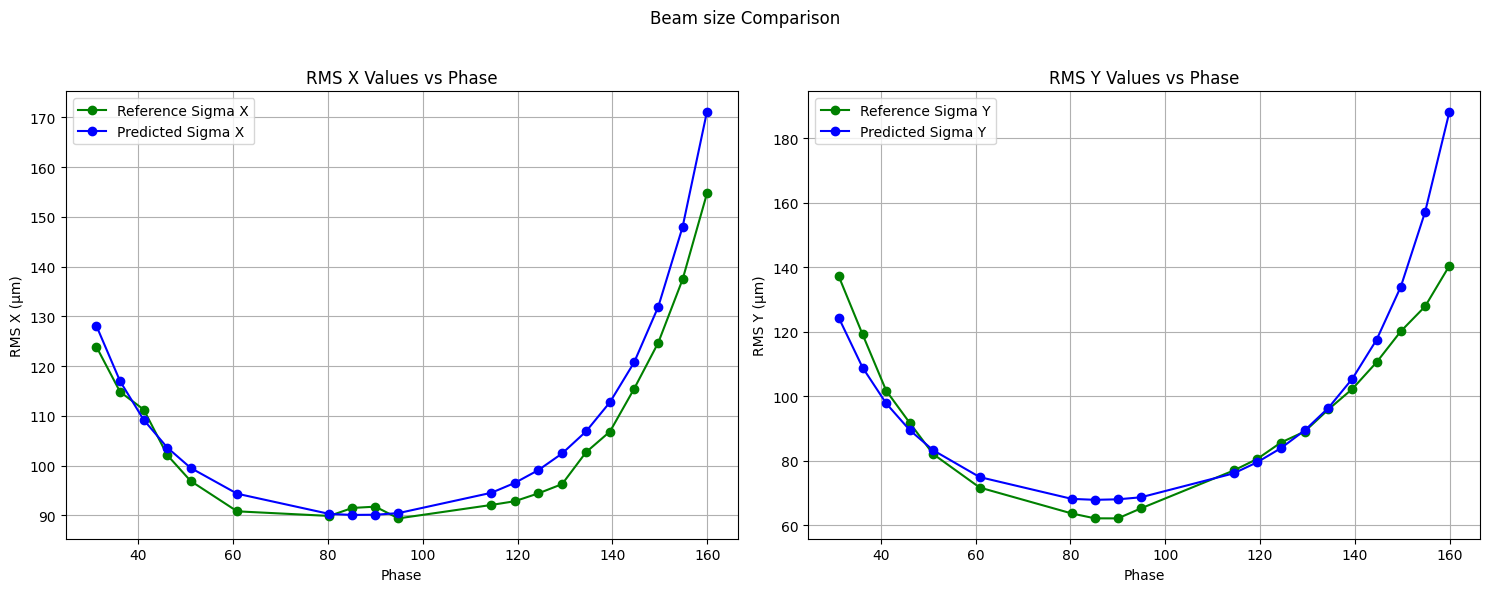

In [15]:
# create_sigma_comparison_with_phase(filtered_phase_design=[filtered_x_phase_design, filtered_y_phase_design], 
create_sigma_comparison(quad_k_np=filtered_x_phase_design, 
                        orig_sigmas_x=orig_rms_x,
                        orig_sigmas_y=orig_rms_y,
                        pred_sigmas_x=pred_rms_x,
                        pred_sigmas_y=pred_rms_y,
                        reconstructed_values=[[k*1e6 for k in filtered_x_reconstructed], [k*1e6 for k in filtered_y_reconstructed]],
                        measurements= [[k*1e6 for k in filtered_x_beamsizes], [k*1e6 for k in filtered_y_beamsizes]],
                        label='RMS',
                        x_label='Phase'
                        )

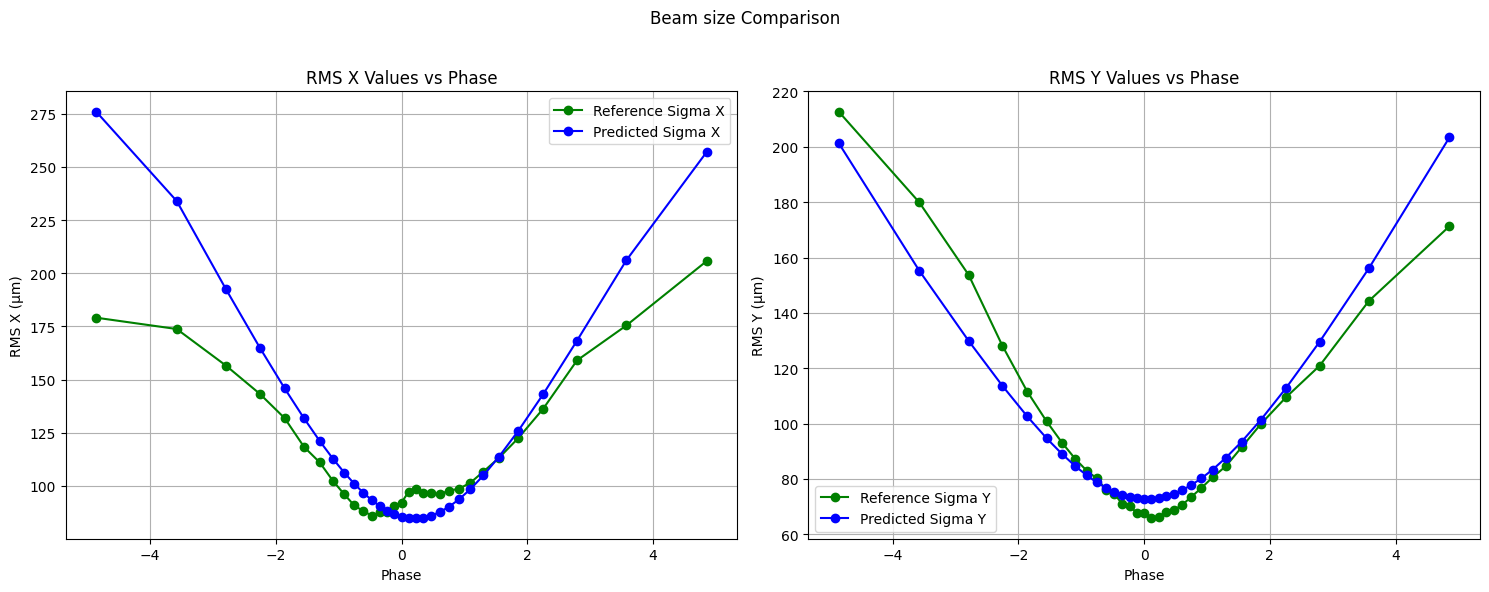

In [41]:
# create_sigma_comparison_with_phase(filtered_phase_design=[filtered_x_phase_design, filtered_y_phase_design], 
create_sigma_comparison(quad_k_np=filtered_quad_k, 
                        orig_sigmas_x=orig_rms_x,
                        orig_sigmas_y=orig_rms_y,
                        pred_sigmas_x=pred_rms_x,
                        pred_sigmas_y=pred_rms_y,
                        reconstructed_values=[[k*1e6 for k in filtered_x_reconstructed], [k*1e6 for k in filtered_y_reconstructed]],
                        measurements= [[k*1e6 for k in filtered_x_beamsizes], [k*1e6 for k in filtered_y_beamsizes]],
                        label='RMS',
                        x_label='Phase'
                        )

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import os

def create_sigma_comparison(quad_k_np, orig_sigmas_x, orig_sigmas_y, pred_sigmas_x, pred_sigmas_y, 
                           reconstructed_values, measurements, label='Sigma', x_label = 'Phase'):
    """
    Create sigma comparison plot and CSV with additional data series
    
    Parameters:
    -----------
    quad_k_np : array
        Quadrupole K values
    orig_sigmas_x, orig_sigmas_y : arrays
        Original sigma values for X and Y
    pred_sigmas_x, pred_sigmas_y : arrays  
        Predicted sigma values for X and Y
    reconstructed_values : array
        Additional reconstructed values to plot
    measurements : array
        Additional measurement values to plot
    """
    
    # Create sigma comparison plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Left subplot: Sigma X and additional data
    axes[0].plot(quad_k_np, orig_sigmas_x, c='red', linestyle='--', label=f'Original image {label} X', marker='o')
    axes[0].plot(quad_k_np, pred_sigmas_x, c='blue', label='Trained with half dataset', marker='o')
    axes[0].plot(quad_k_np, reconstructed_values, c='green', label='Trained with full dataset', marker='o')
    # axes[0].plot(quad_k_np, measurements[0], c='green', linestyle='--', label='Measurements', marker='d')
    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel(f'{label} X (µm)')
    axes[0].set_title(f'{label} X Values vs {x_label}')
    axes[0].legend()
    axes[0].grid(True)
    
    # Right subplot: Sigma Y and additional data
    axes[1].plot(quad_k_np, orig_sigmas_y, c='red', linestyle='--', label=f'Original image {label} Y', marker='o')
    axes[1].plot(quad_k_np, pred_sigmas_y, c='blue', label='Trained with half dataset', marker='o')
    axes[1].plot(quad_k_np, measurements, c='green', label='Trained with full dataset', marker='o')
    # axes[1].plot(quad_k_np, measurements[1], c='green', linestyle='--', label='Measurements', marker='d')
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(f'{label} Y (µm)')
    axes[1].set_title(f'{label} Y Values vs Quad K')
    axes[1].legend()
    axes[1].grid(True)
    
    fig.suptitle('Beam size Comparison')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def create_sigma_comparison_with_phase(filtered_phase_design, orig_sigmas_x, orig_sigmas_y, pred_sigmas_x, pred_sigmas_y, 
                           reconstructed_values, measurements, label='Sigma',x_label = 'Phase'):
    """
    Create sigma comparison plot and CSV with additional data series
    
    Parameters:
    -----------
    quad_k_np : array
        Quadrupole K values
    orig_sigmas_x, orig_sigmas_y : arrays
        Original sigma values for X and Y
    pred_sigmas_x, pred_sigmas_y : arrays  
        Predicted sigma values for X and Y
    reconstructed_values : array
        Additional reconstructed values to plot
    measurements : array
        Additional measurement values to plot
    """
    
    # Create sigma comparison plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Left subplot: Sigma X and additional data
    axes[0].plot(filtered_phase_design[0], orig_sigmas_x, c='red', linestyle='--', label=f'Original image {label} X', marker='o')
    axes[0].plot(filtered_phase_design[0], pred_sigmas_x, c='blue', label='With SCP', marker='o')
    axes[0].plot(filtered_phase_design[0], reconstructed_values, c='green', label='Without SCP', marker='o')
    # axes[0].plot(filtered_phase_design[0], measurements[0], c='green', label='Measurements', marker='d')
    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel(f'{label} X (µm)')
    axes[0].set_title(f'{label} X Values vs {x_label}')
    axes[0].legend()
    axes[0].grid(True)
    
    # Right subplot: Sigma Y and additional data
    axes[1].plot(filtered_phase_design[1], orig_sigmas_y, c='red', linestyle='--', label='Original image Sigma Y', marker='o')
    axes[1].plot(filtered_phase_design[1], pred_sigmas_y, c='blue', label='With SCP', marker='o')
    axes[1].plot(filtered_phase_design[1], measurements, c='green', label='Without SCP', marker='o')
    # axes[1].plot(filtered_phase_design[1], measurements[1], c='green', label='Measurements', marker='d')
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(f'{label} Y (µm)')
    axes[1].set_title(f'{label} Y Values vs {x_label}')
    axes[1].legend()
    axes[1].grid(True)
    
    fig.suptitle('Beam size Comparison')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

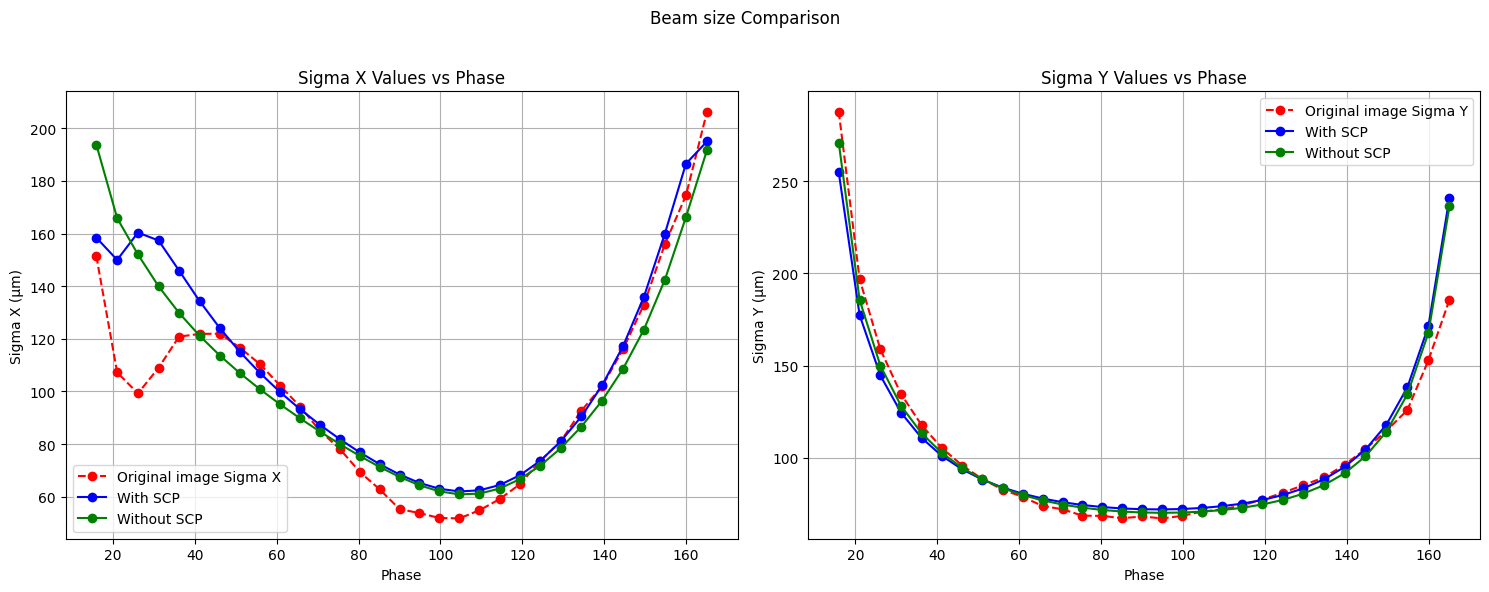

In [43]:
create_sigma_comparison_with_phase(filtered_phase_design=[filtered_x_phase_design, filtered_y_phase_design], 
# create_sigma_comparison(quad_k_np=filtered_quad_k, 
                        orig_sigmas_x=orig_sigmas_x,
                        orig_sigmas_y=orig_sigmas_y,
                        pred_sigmas_x=pred_sigmas_x,
                        pred_sigmas_y=pred_sigmas_y,
                        reconstructed_values=pred_sigmas_x2,
                        measurements= pred_sigmas_y2
                        )

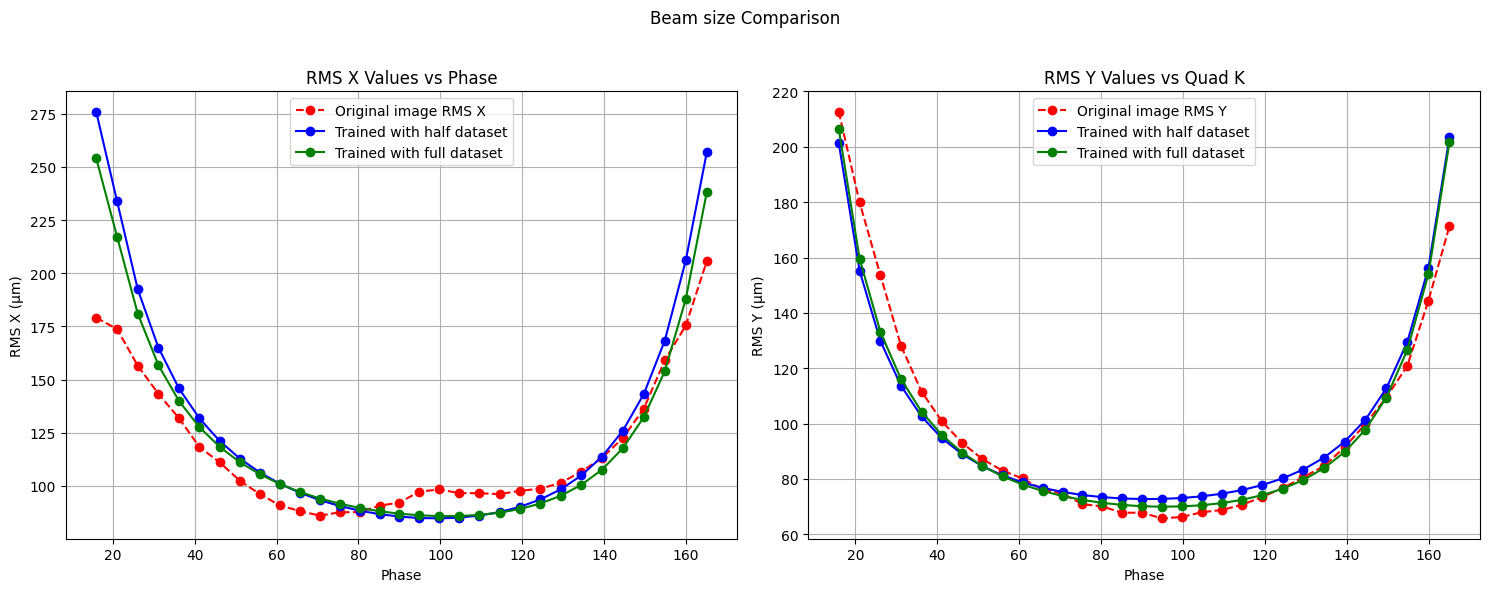

In [44]:
# create_sigma_comparison_with_phase(filtered_phase_design=[filtered_x_phase_design, filtered_y_phase_design], 
create_sigma_comparison(quad_k_np=filtered_x_phase_design, 
                        orig_sigmas_x=orig_rms_x,
                        orig_sigmas_y=orig_rms_y,
                        pred_sigmas_x=pred_rms_x,
                        pred_sigmas_y=pred_rms_y,
                        reconstructed_values=pred_rms_x2,
                        measurements= pred_rms_y2,
                        label='RMS'
                        )

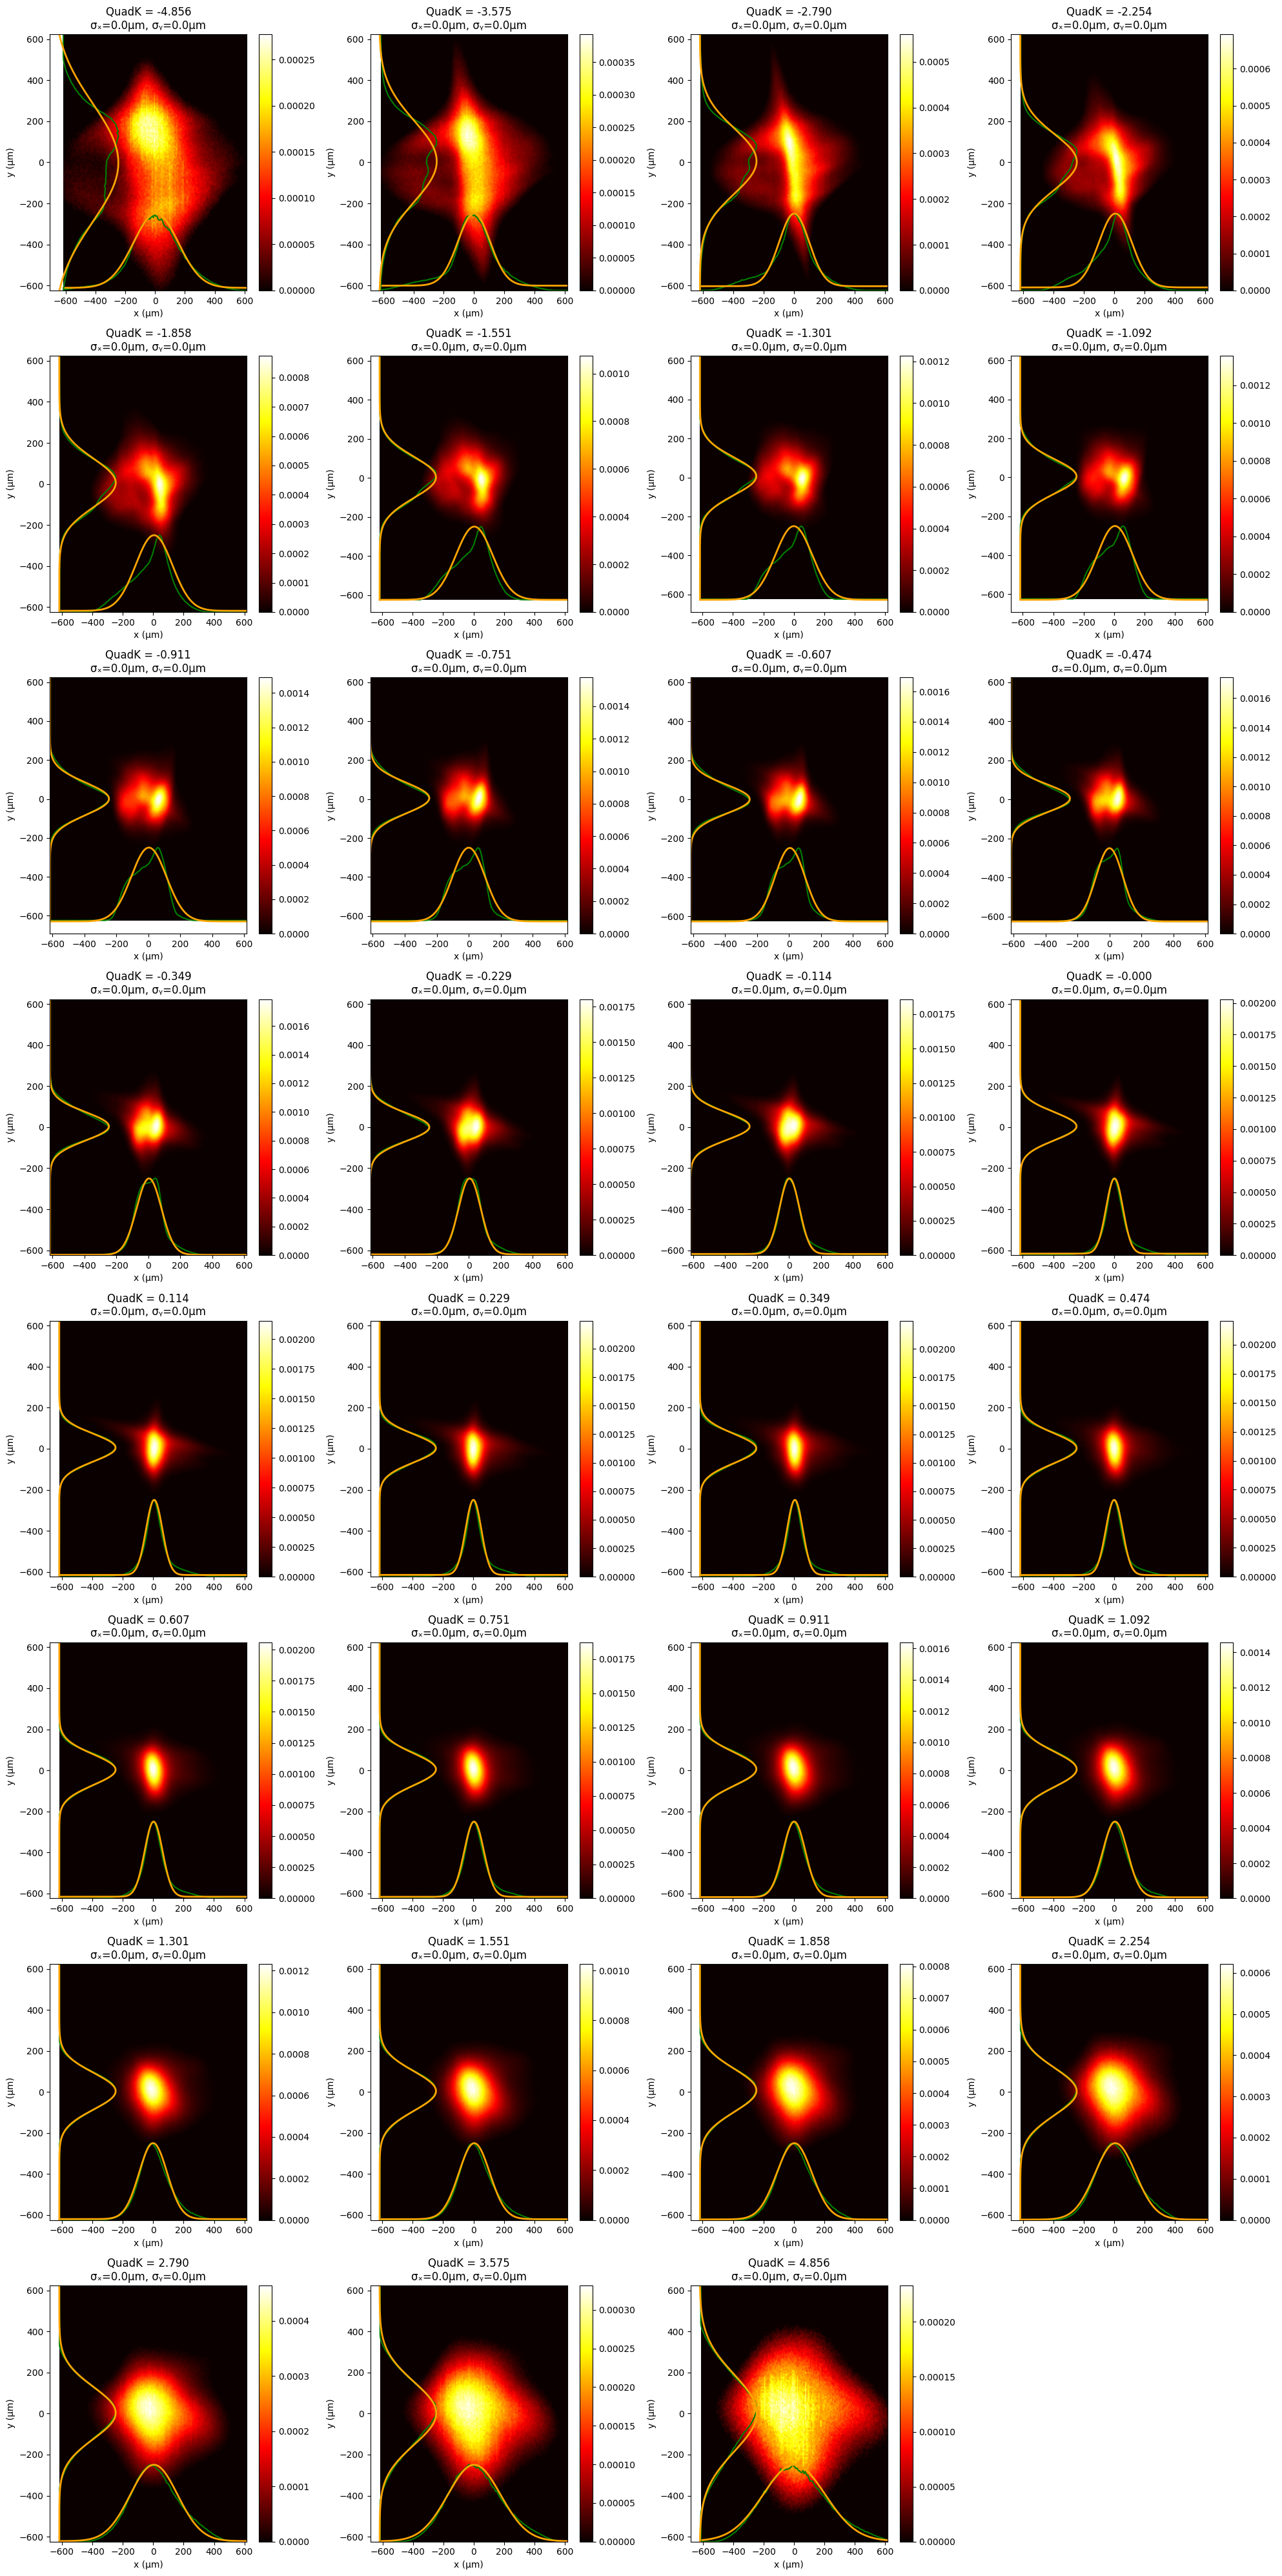

[{'gf_x': <ps_reconstruction.utils.visualization.plot_images_with_proj.<locals>.FitResult at 0x7fe974e65c70>,
  'gf_y': <ps_reconstruction.utils.visualization.plot_images_with_proj.<locals>.FitResult at 0x7fe9715ca2a0>,
  'sigma_x': np.float64(0.0001513115379761965),
  'sigma_y': np.float64(0.0002894677542085588),
  'imshow_outp': <matplotlib.image.AxesImage at 0x7fe97155d6d0>,
  'plot_gauss_y_outp': [<matplotlib.lines.Line2D at 0x7fe970f1c770>],
  'plot_proj_y_outp': [<matplotlib.lines.Line2D at 0x7fe970f1c5f0>],
  'plot_gauss_x_outp': [<matplotlib.lines.Line2D at 0x7fe970f1c350>],
  'plot_proj_x_outp': [<matplotlib.lines.Line2D at 0x7fe9710e7ec0>],
  'extent': [np.float32(-616.0),
   np.float32(616.0),
   np.float32(-624.0),
   np.float32(624.0)]},
 {'gf_x': <ps_reconstruction.utils.visualization.plot_images_with_proj.<locals>.FitResult at 0x7fe972ea9700>,
  'gf_y': <ps_reconstruction.utils.visualization.plot_images_with_proj.<locals>.FitResult at 0x7fe970f45040>,
  'sigma_x': np.flo

In [13]:
from ps_reconstruction.utils.visualization import prepare_images_for_plotting, plot_images_with_proj

images_for_plotting = prepare_images_for_plotting(processed_tensors, filtered_quad_k, lattice)

plot_images_with_proj(images_for_plotting, x_pixel_size=7.7e-6, y_pixel_size=7.8e-6)

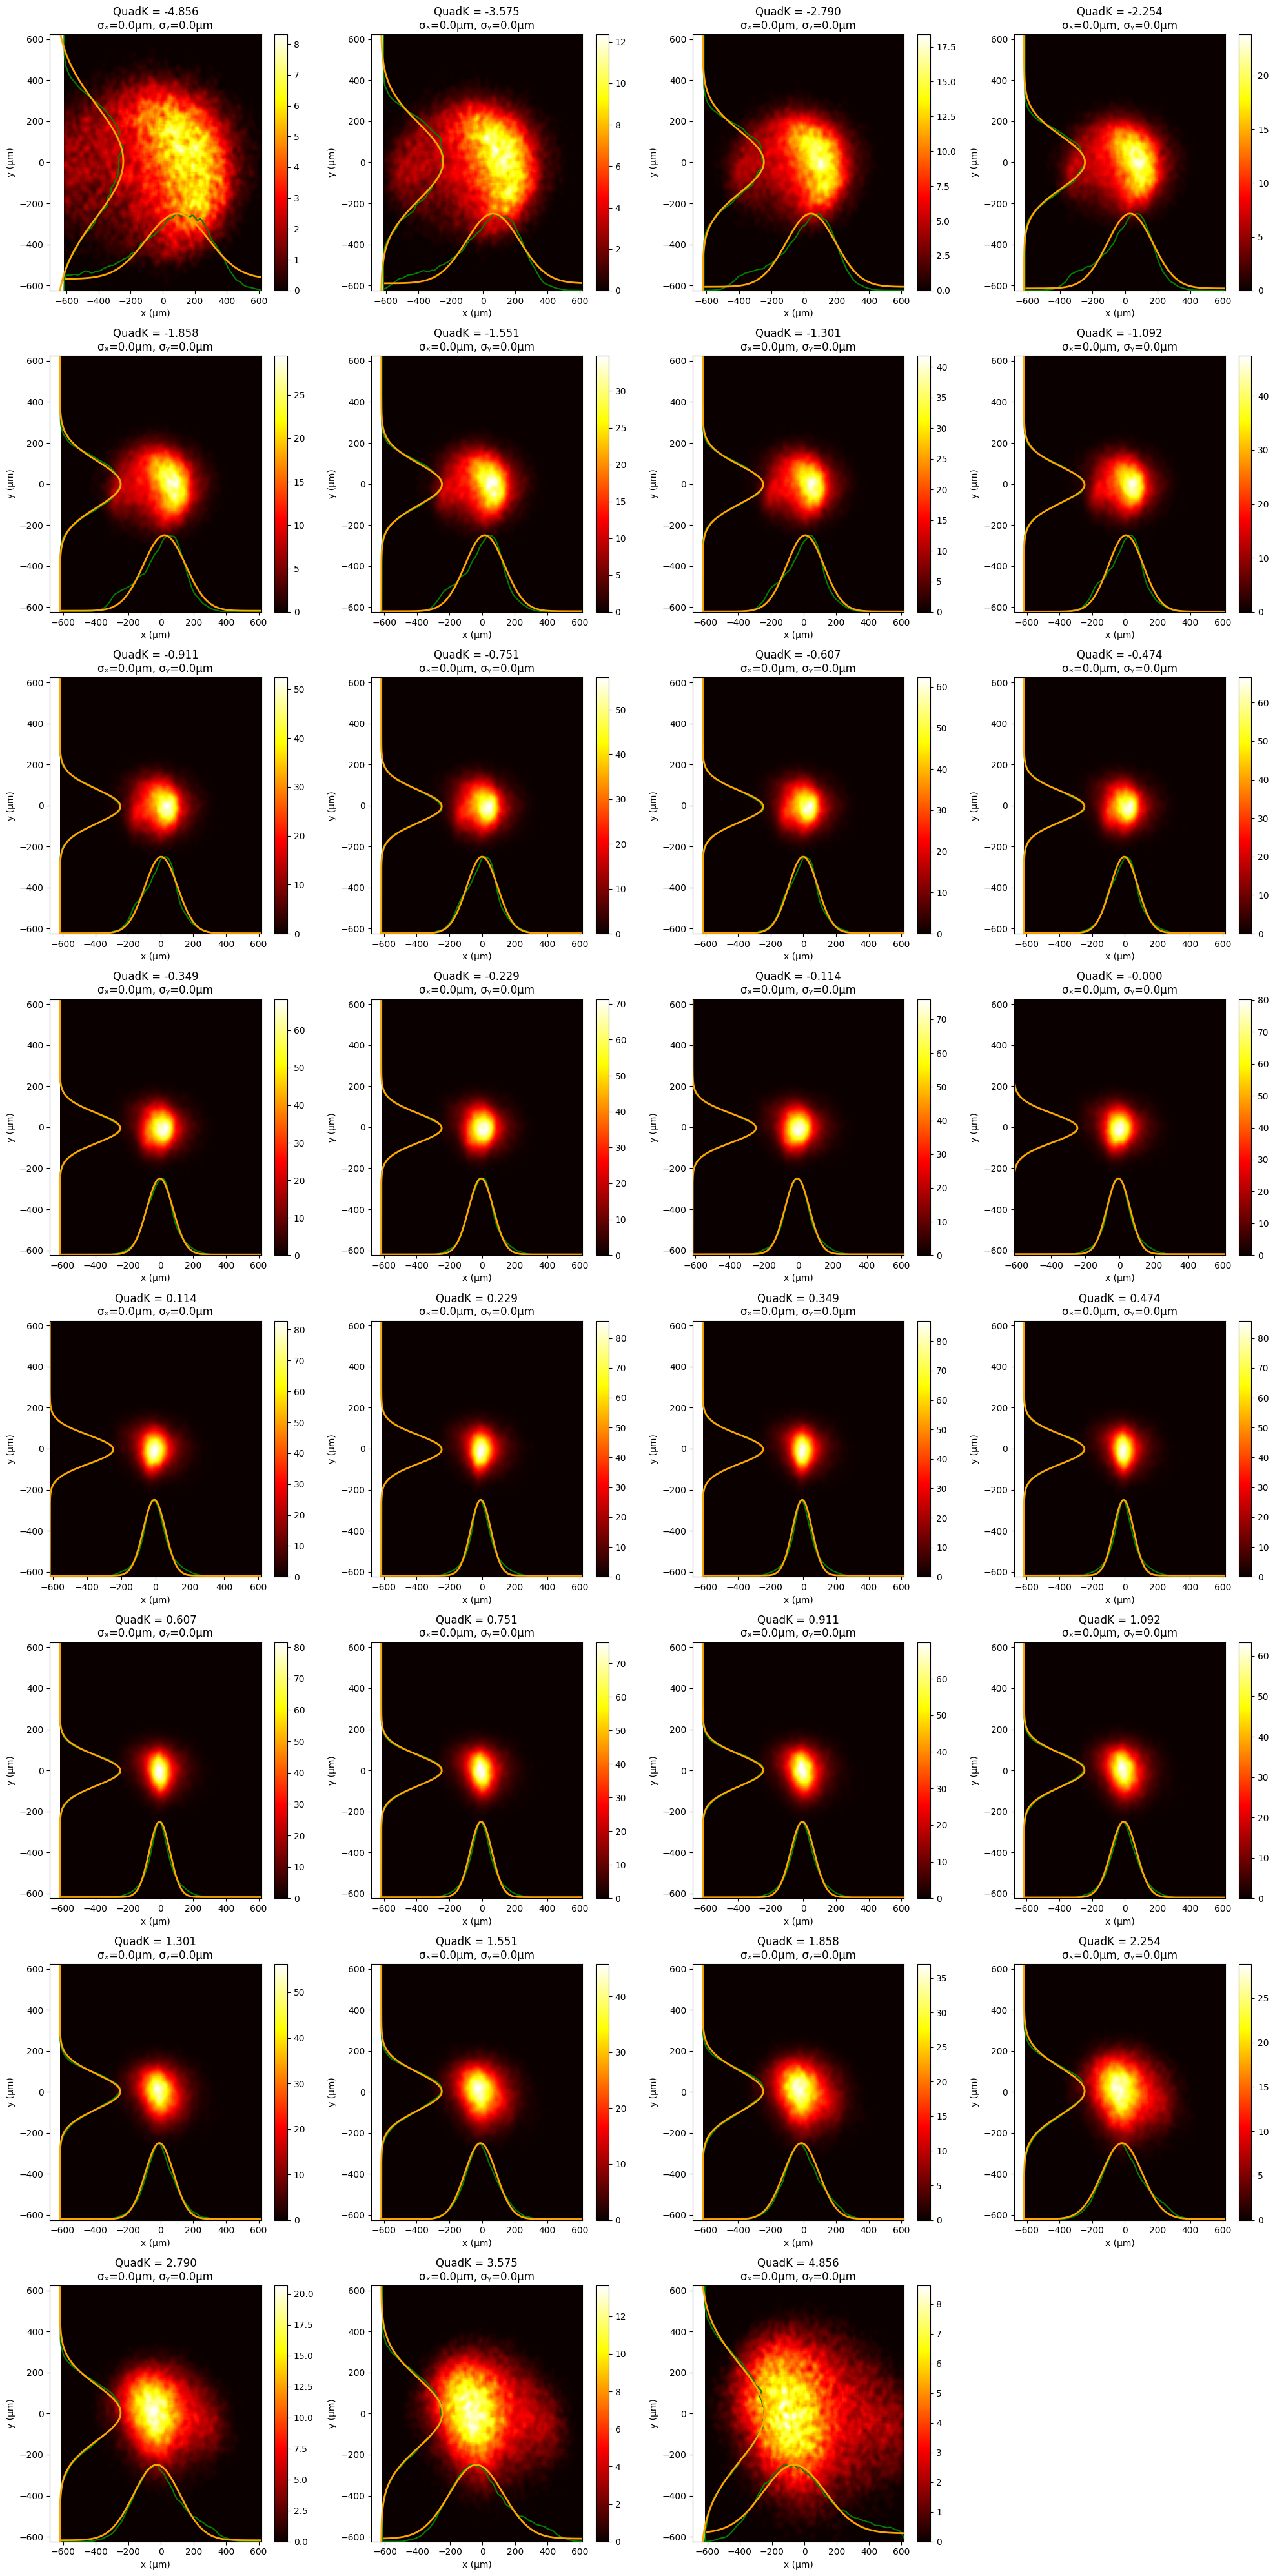

[{'gf_x': <ps_reconstruction.utils.visualization.plot_images_with_proj.<locals>.FitResult at 0x7fe96e12aae0>,
  'gf_y': <ps_reconstruction.utils.visualization.plot_images_with_proj.<locals>.FitResult at 0x7fe9705ad5b0>,
  'sigma_x': np.float64(0.0001936751783654729),
  'sigma_y': np.float64(0.00027263367422160903),
  'imshow_outp': <matplotlib.image.AxesImage at 0x7fe9706d5c40>,
  'plot_gauss_y_outp': [<matplotlib.lines.Line2D at 0x7fe9705ae7e0>],
  'plot_proj_y_outp': [<matplotlib.lines.Line2D at 0x7fe9705ae2d0>],
  'plot_gauss_x_outp': [<matplotlib.lines.Line2D at 0x7fe9705ae060>],
  'plot_proj_x_outp': [<matplotlib.lines.Line2D at 0x7fe9705adc40>],
  'extent': [np.float32(-616.0),
   np.float32(616.0),
   np.float32(-624.0),
   np.float32(624.0)]},
 {'gf_x': <ps_reconstruction.utils.visualization.plot_images_with_proj.<locals>.FitResult at 0x7fe970911700>,
  'gf_y': <ps_reconstruction.utils.visualization.plot_images_with_proj.<locals>.FitResult at 0x7fe96e41a690>,
  'sigma_x': np.fl

In [14]:
images_for_plotting = prepare_images_for_plotting(generated_images, filtered_quad_k, lattice)

plot_images_with_proj(images_for_plotting, x_pixel_size=7.7e-6, y_pixel_size=7.8e-6)

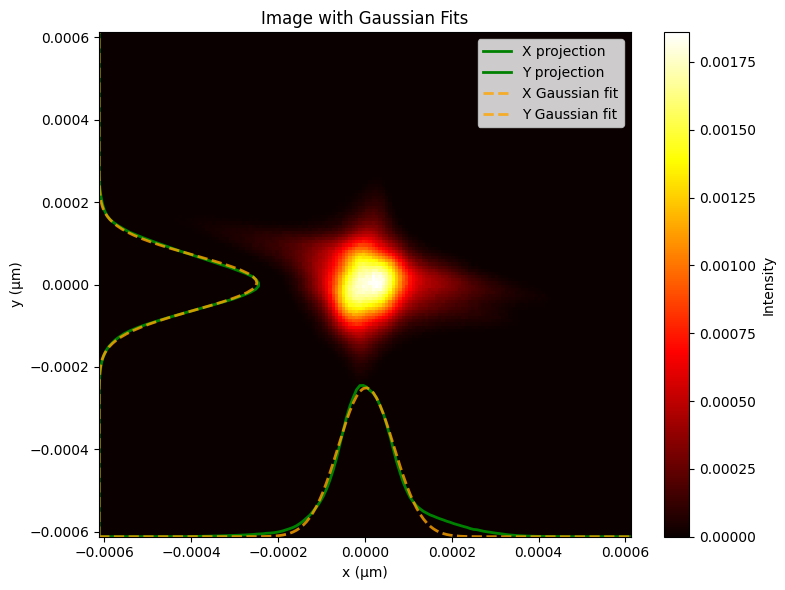

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def gaussian(x, amplitude, mean, sigma, offset=0):
    """Gaussian function for fitting"""
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2)) + offset

class GaussFit:
    def __init__(self, x, y, fit_const=True):
        self.x = x
        self.y = y
        self.fit_const = fit_const
        self.popt, self.pcov = self.fit()
        self.reconstruction = self.gaussian(x, *self.popt)

    def gaussian(self, x, *p):
        A, mu, sigma = p[:3]
        y = A*np.exp(-(x-mu)**2/(2.*sigma**2))
        if self.fit_const:
            y = y + p[3]
        return y

    def fit(self):
        mean = self.x[np.argmax(self.y)]
        sigma = ((self.x - mean)**2 * self.y).sum() / self.y.sum()
        sigma = np.sqrt(sigma)
        p0 = [self.y.max(), mean, sigma]
        if self.fit_const:
            p0.append(0)
        try:
            popt, pcov = curve_fit(self.gaussian, self.x, self.y, p0=p0)
        except RuntimeError:
            print('Gauss fit failed')
            popt = p0
            pcov = np.zeros((len(p0), len(p0)))
        return popt, pcov

def plot_single_image_with_gauss(image, image_shape = (120, 120), pixel_size=1.0, cmapname='hot', 
                                gauss_color=('orange', 'orange'), 
                                proj_color=('green', 'green'),
                                gauss_alpha=0.8, figsize=(8, 6)):
    """
    Plot a single 120x120 image with Gaussian fits to projections
    
    Parameters:
    -----------
    image : numpy.ndarray
        2D array of shape (120, 120)
    pixel_size : float
        Pixel size in micrometers (default: 1.0)
    cmapname : str
        Colormap name (default: 'hot')
    gauss_color : tuple
        Colors for Gaussian fits (default: ('orange', 'orange'))
    proj_color : tuple
        Colors for projections (default: ('green', 'green'))
    gauss_alpha : float
        Alpha value for Gaussian fits (default: 0.8)
    figsize : tuple
        Figure size (default: (8, 6))
    
    Returns:
    --------
    dict : Dictionary containing fit results and plot objects
    """

    
    # if image.shape != (120, 120):
    #     raise ValueError(f"Expected image shape (120, 120), got {image.shape}")
    
    # Create coordinate arrays
    x_coords = np.arange(image_shape[0]) * pixel_size
    y_coords = np.arange(image_shape[1]) * pixel_size
    
    # Calculate extent for imshow (centered coordinates)
    x_center = x_coords - x_coords.mean()
    y_center = y_coords - y_coords.mean()
    extent = [x_center[0], x_center[-1], y_center[0], y_center[-1]]
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Plot image
    imshow_outp = ax.imshow(image, aspect='auto', extent=extent, 
                           origin='lower', cmap=plt.get_cmap(cmapname))
    
    # Calculate projections
    x_proj = image.sum(axis=0)  # Sum along y-axis for x-projection
    y_proj = image.sum(axis=1)  # Sum along x-axis for y-projection
    
    # Normalize and scale projections for overlay
    x_proj_norm = x_proj / x_proj.max()
    y_proj_norm = y_proj / y_proj.max()
    
    # Scale projections to 30% of the image range for overlay
    y_range = y_center[-1] - y_center[0]
    x_range = x_center[-1] - x_center[0]
    
    x_proj_scaled = y_center[0] + y_range * x_proj_norm * 0.3
    y_proj_scaled = x_center[0] + x_range * y_proj_norm * 0.3
    
    # Plot projections
    plot_proj_x = ax.plot(x_center, x_proj_scaled, color=proj_color[0], 
                         linewidth=2, label='X projection')
    plot_proj_y = ax.plot(y_proj_scaled, y_center, color=proj_color[1], 
                         linewidth=2, label='Y projection')
    
    # Fit Gaussians
    gf_x = GaussFit(x_center, x_proj_scaled - x_proj_scaled.min(), fit_const=False)
    gf_y = GaussFit(y_center, y_proj_scaled - y_proj_scaled.min(), fit_const=False)
    
    # Plot Gaussian fits
    plot_gauss_x = ax.plot(x_center, gf_x.reconstruction + x_proj_scaled.min(), 
                          color=gauss_color[0], alpha=gauss_alpha, linewidth=2,
                          linestyle='--', label='X Gaussian fit')
    plot_gauss_y = ax.plot(gf_y.reconstruction + y_proj_scaled.min(), y_center, 
                          color=gauss_color[1], alpha=gauss_alpha, linewidth=2,
                          linestyle='--', label='Y Gaussian fit')
    
    # Set labels and title
    ax.set_xlabel("x (μm)")
    ax.set_ylabel("y (μm)")
    ax.set_title("Image with Gaussian Fits")
    
    # Add colorbar
    cbar = fig.colorbar(imshow_outp, ax=ax)
    cbar.set_label('Intensity')
    
    # Add legend
    ax.legend(loc='upper right', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    plt.show()
    
    # Return results
    return {
        'gf_x': gf_x,
        'gf_y': gf_y,
        'imshow_outp': imshow_outp,
        'plot_gauss_x': plot_gauss_x,
        'plot_gauss_y': plot_gauss_y,
        'plot_proj_x': plot_proj_x,
        'plot_proj_y': plot_proj_y,
        'extent': extent,
        'x_coords': x_center,
        'y_coords': y_center,
        'x_projection': x_proj,
        'y_projection': y_proj
    }

# Plot the test image
result = plot_single_image_with_gauss(processed_images_array[14], image_shape=(160,160), pixel_size=7.7e-6)

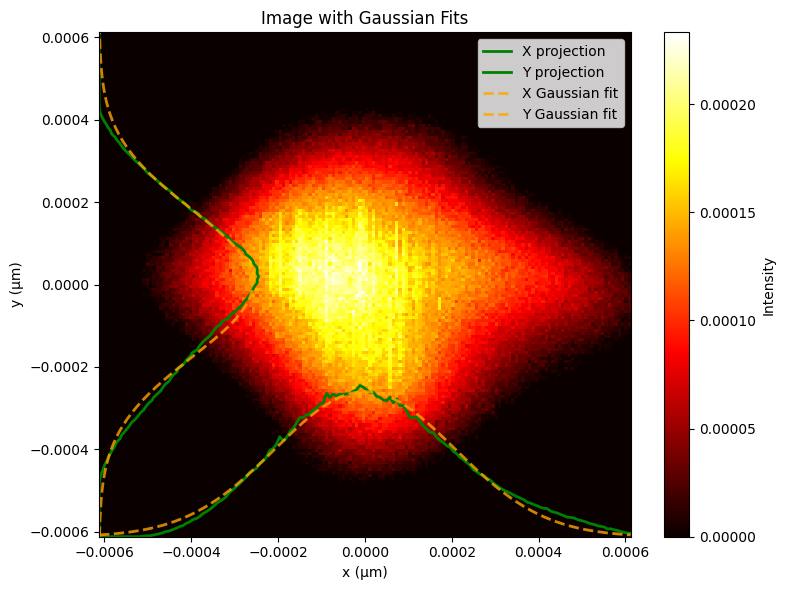

In [8]:
result = plot_single_image_with_gauss(processed_images_array[30], image_shape=(160,160), pixel_size=7.7e-6)